<table align="left">
  <td><a target="_blank" href="https://colab.research.google.com/github/anvasquezre/EAFIT_AA_2026-02/blob/main/notebooks/06_ml_clustering_anomalias.ipynb"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Abrir en Colab"/></a></td>
  <td><a target="_blank" href="https://kaggle.com/kernels/welcome?src=https://github.com/anvasquezre/EAFIT_AA_2026-02/blob/main/notebooks/06_ml_clustering_anomalias.ipynb"><img src="https://kaggle.com/static/images/open-in-kaggle.svg" alt="Abrir en Kaggle"/></a></td>
</table>
<br><br>

# Clustering, anomalías y confiabilidad

**Curso:** Aprendizaje Automático — SI7009 - 1 (5553)
**Sesión 6:** Clustering, anomalías y confiabilidad
**Universidad:** EAFIT
**Profesor:** Andrés Vásquez Restrepo
**Dataset:** Olist (Brazilian E-Commerce): 1.740 vendedores (mismos de la sesión 5) y ~90 mil órdenes para drift

---

**Objetivo:** proponer grupos sin etiquetas, decidir si sirven como segmentos, encontrar lo que no encaja y detectar cuando el mundo cambia.

### Cómo trabajar este notebook

El código está en la celda de herramientas. Cada sección tiene **una línea** que produce una gráfica o tabla, y debajo la lectura.

| Marca | Qué hacer |
|---|---|
| 🔮 **Prediga** | antes de ejecutar, diga qué espera ver |
| 👀 **Qué mirar** | dónde poner los ojos en la gráfica |
| 💬 **Discuta** | pregunta para responder en parejas; la respuesta va debajo |

### Mapa

| Sección | Pregunta |
|---|---|
| 3. Mini-mundo | ¿Qué hacen K-Means, la silueta y DBSCAN con 6 puntos? |
| 4. K-Means | ¿Cuándo falla? ¿Importa el inicio? ¿Mini-Batch? |
| 5. Otras familias | ¿Qué ven el jerárquico y los métodos de densidad? |
| 6. Elegir $k$ | ¿Qué dicen el codo, la silueta y la estabilidad? |
| 7. Segmentos | ¿Qué grupos de vendedores hay y qué hacemos con cada uno? |
| 8. Outliers | ¿Quién no encaja? |
| 9. Drift | ¿Cambió el mundo después de entrenar? |

<a name="1"></a>
## 1. Cómo ejecutar

**Local con `uv`**: `uv sync` y luego `uv run jupyter lab notebooks/06_ml_clustering_anomalias.ipynb`.

**Colab / Kaggle:** ejecutar la celda siguiente. Los CSV de Olist se descargan con `kagglehub`.

In [1]:
import os
import subprocess
import sys

if "google.colab" in sys.modules or "KAGGLE_KERNEL_RUN_TYPE" in os.environ:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "umap-learn", "duckdb", "kagglehub", "scikit-learn>=1.5"], check=True)
    print("Cloud environment: dependencies installed.")
else:
    print("Local environment: dependencies come from pyproject.toml / uv.lock (run `uv sync`).")

Local environment: dependencies come from pyproject.toml / uv.lock (run `uv sync`).


<a name="2"></a>
## 2. Herramientas de la sesión

Ejecute la celda siguiente (está plegada). **No hace falta leerla.**

In [2]:
#@title Herramientas de la sesión (ejecutar; no hace falta leer)

from __future__ import annotations

import time
import warnings
from pathlib import Path

import duckdb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from matplotlib.colors import LinearSegmentedColormap
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")
SEED = 42

# ---------------------------------------------------------------- style
INK, INK2, GRID = "#333333", "#656565", "#DBDBDC"
SERIES = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300", "#8c5ac8"]
NOISE = "#b5b5b5"
BLUES = LinearSegmentedColormap.from_list("blues", ["#cde2fb", "#6da7ec", "#2a78d6", "#184f95", "#0d366b"])
DIVERGING = LinearSegmentedColormap.from_list("div", ["#2a78d6", "#f2f2f2", "#eb6834"])
plt.rcParams.update({
    "figure.dpi": 100, "font.size": 11, "axes.titlesize": 12, "axes.edgecolor": INK2,
    "axes.labelcolor": INK, "xtick.color": INK2, "ytick.color": INK2, "text.color": INK,
    "axes.spines.top": False, "axes.spines.right": False, "axes.grid": True,
    "grid.color": GRID, "grid.linewidth": 0.6, "legend.frameon": False,
})


def clean_ax(ax):
    ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
    for s in ax.spines.values():
        s.set_visible(False)


def colors_for(labels):
    return [NOISE if l < 0 else SERIES[l % len(SERIES)] for l in labels]


# ---------------------------------------------------------------- Olist data
TABLES = {
    "orders": "olist_orders_dataset.csv",
    "order_items": "olist_order_items_dataset.csv",
    "order_reviews": "olist_order_reviews_dataset.csv",
    "sellers": "olist_sellers_dataset.csv",
    "products": "olist_products_dataset.csv",
}


def olist_connection() -> duckdb.DuckDBPyConnection:
    """In-memory DuckDB with one view per Olist CSV (downloaded with kagglehub)."""
    import kagglehub

    csv_dir = Path(kagglehub.dataset_download("olistbr/brazilian-ecommerce"))
    con = duckdb.connect()
    for table, filename in TABLES.items():
        con.execute(f"CREATE VIEW {table} AS SELECT * FROM read_csv_auto('{csv_dir / filename}')")
    return con


SELLERS_SQL = """
WITH items AS (
    SELECT oi.seller_id, oi.order_id, oi.price, oi.freight_value, p.product_category_name AS cat
    FROM order_items oi
    JOIN orders o USING (order_id)
    LEFT JOIN products p USING (product_id)
    WHERE o.order_status = 'delivered'
      AND o.order_purchase_timestamp < TIMESTAMP '2018-06-01'
),
ord AS (
    SELECT DISTINCT i.seller_id, o.order_id,
           o.order_delivered_customer_date > o.order_estimated_delivery_date AS late,
           date_diff('hour', o.order_approved_at, o.order_delivered_carrier_date) / 24.0 AS handling_days
    FROM items i JOIN orders o USING (order_id)
),
rev AS (SELECT order_id, avg(review_score) AS score FROM order_reviews GROUP BY order_id)
SELECT s.seller_id,
       any_value(se.seller_state)                    AS state,
       sum(s.price)                                  AS revenue,
       count(DISTINCT s.order_id)                    AS n_orders,
       sum(s.price) / count(DISTINCT s.order_id)     AS ticket,
       sum(s.freight_value) / sum(s.price)           AS freight_ratio,
       count(DISTINCT s.cat)                         AS n_categories,
       (SELECT avg(late::INT) FROM ord WHERE ord.seller_id = s.seller_id)        AS late_rate,
       (SELECT median(handling_days) FROM ord WHERE ord.seller_id = s.seller_id) AS handling_days,
       (SELECT avg(r.score) FROM ord JOIN rev r USING (order_id)
         WHERE ord.seller_id = s.seller_id)                                      AS review_mean
FROM items s JOIN sellers se USING (seller_id)
GROUP BY s.seller_id
HAVING count(DISTINCT s.order_id) >= 3
"""

FEATURES = ["revenue", "n_orders", "ticket", "freight_ratio", "n_categories",
            "late_rate", "handling_days", "review_mean"]
LOG_FEATURES = ["revenue", "n_orders", "ticket", "n_categories", "handling_days"]
LABELS_ES = {
    "revenue": "ventas", "n_orders": "nº órdenes", "ticket": "ticket medio",
    "freight_ratio": "flete / precio", "n_categories": "nº categorías",
    "late_rate": "% retraso", "handling_days": "días a transportadora", "review_mean": "calificación",
}
REGION = {"SP": "Sudeste", "RJ": "Sudeste", "MG": "Sudeste", "ES": "Sudeste",
          "PR": "Sur", "SC": "Sur", "RS": "Sur",
          "DF": "Centro-Oeste", "GO": "Centro-Oeste", "MT": "Centro-Oeste", "MS": "Centro-Oeste"}


def load_sellers(con) -> pd.DataFrame:
    """One row per seller with >= 3 delivered orders before 2018-06-01."""
    df = con.sql(SELLERS_SQL).df().dropna(subset=FEATURES)
    df = df.sort_values("seller_id").reset_index(drop=True)  # GROUP BY has no fixed order
    df["handling_days"] = df["handling_days"].clip(lower=0)
    df["region"] = df["state"].map(REGION).fillna("Norte/Nordeste")
    return df


def prepare(df: pd.DataFrame) -> np.ndarray:
    """log1p on skewed columns, then StandardScaler."""
    X = df[FEATURES].copy()
    for c in LOG_FEATURES:
        X[c] = np.log1p(X[c])
    return StandardScaler().fit_transform(X)


def run_umap(X, seed=SEED, **kw):
    import umap

    return umap.UMAP(random_state=seed, **kw).fit_transform(X)


def scatter_by_value(ax, Y, values, title, cmap=BLUES):
    ax.scatter(Y[:, 0], Y[:, 1], s=6, c=values, cmap=cmap, linewidths=0)
    ax.set_title(title); clean_ax(ax)


def scatter_by_region(ax, Y, df, title, legend=False):
    for i, r in enumerate(["Sudeste", "Sur", "Centro-Oeste", "Norte/Nordeste"]):
        m = (df["region"] == r).to_numpy()
        ax.scatter(Y[m, 0], Y[m, 1], s=6, c=SERIES[i], alpha=0.75, linewidths=0, label=r)
    ax.set_title(title); clean_ax(ax)
    if legend:
        ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.02), ncol=4, markerscale=3)


# mini-mundo de las slides
MINI = pd.DataFrame([[1, 2], [2, 1], [2, 3], [6, 5], [7, 7], [8, 6]],
                    index=list("ABCDEF"), columns=["x1", "x2"], dtype=float)

from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.stats import ks_2samp
from sklearn.cluster import DBSCAN, HDBSCAN, AgglomerativeClustering, KMeans, MiniBatchKMeans
from sklearn.datasets import make_blobs, make_moons
from sklearn.ensemble import IsolationForest
from sklearn.metrics import (adjusted_rand_score, calinski_harabasz_score, davies_bouldin_score,
                             silhouette_samples, silhouette_score)
from sklearn.neighbors import LocalOutlierFactor, NearestNeighbors

MINI_G = pd.concat([MINI, pd.DataFrame([[5, 1]], index=["G"], columns=["x1", "x2"], dtype=float)])


def _mini_ax(ax, pts, colors, title):
    ax.scatter(pts.x1, pts.x2, s=90, c=colors, zorder=3)
    for n, (a, b) in pts.iterrows():
        ax.annotate(n, (a, b), xytext=(5, 5), textcoords="offset points")
    ax.set_xlim(0, 9); ax.set_ylim(0, 8); ax.set_aspect("equal"); ax.set_title(title)


def lloyd_by_hand(init=("A", "B"), max_iter=5):
    """K-Means (k=2) on the mini-world, one panel per iteration."""
    P = MINI.to_numpy()
    mu = MINI.loc[list(init)].to_numpy()
    rows, panels = [], []
    for it in range(1, max_iter + 1):
        lab = ((P[:, None] - mu) ** 2).sum(2).argmin(1)
        panels.append((lab.copy(), mu.copy()))
        new_mu = np.array([P[lab == k].mean(0) for k in range(2)])
        groups = " / ".join("{" + ", ".join(MINI.index[lab == k]) + "}" for k in range(2))
        rows.append({"iteración": it, "asignación": groups,
                     "centroide 1": tuple(new_mu[0].round(2)), "centroide 2": tuple(new_mu[1].round(2))})
        if np.allclose(new_mu, mu):
            break
        mu = new_mu
    fig, axes = plt.subplots(1, len(panels), figsize=(4 * len(panels), 3.8))
    for ax, (lab, m), r in zip(np.atleast_1d(axes), panels, rows):
        _mini_ax(ax, MINI, [SERIES[l] for l in lab], f"iteración {r['iteración']}")
        ax.scatter(m[:, 0], m[:, 1], marker="X", s=200, c=INK, zorder=4)
    plt.show()
    J = sum(((P[lab == k] - P[lab == k].mean(0)) ** 2).sum() for k in range(2))
    print(f"inercia final J = {J:.2f}")
    return pd.DataFrame(rows).set_index("iteración")


def silhouette_by_hand(point="A"):
    P = MINI.to_numpy(); lab = np.array([0, 0, 0, 1, 1, 1])
    i = list(MINI.index).index(point)
    d = np.linalg.norm(P - P[i], axis=1)
    same = (lab == lab[i]) & (np.arange(6) != i)
    a, b = d[same].mean(), d[lab != lab[i]].mean()
    print(f"a({point}) = distancia media a su grupo   = {a:.2f}")
    print(f"b({point}) = distancia media al otro grupo = {b:.2f}")
    print(f"s({point}) = (b - a) / max(a, b)           = {(b - a) / max(a, b):.2f}")


def dbscan_by_hand(eps=2.3, min_samples=3):
    lab = DBSCAN(eps=eps, min_samples=min_samples).fit_predict(MINI_G.to_numpy())
    fig, ax = plt.subplots(figsize=(5, 4.2))
    _mini_ax(ax, MINI_G, colors_for(lab), f"DBSCAN eps={eps}, min_samples={min_samples}")
    for (a, b) in MINI_G.to_numpy():
        ax.add_patch(plt.Circle((a, b), eps, fill=False, color=GRID))
    plt.show()
    return pd.Series(lab, index=MINI_G.index, name="etiqueta (-1 = ruido)").to_frame().T


def plot_kmeans_failures():
    rng = np.random.default_rng(SEED)
    Xm, _ = make_moons(500, noise=.06, random_state=SEED)
    Xa, _ = make_blobs(500, centers=3, random_state=170); Xa = Xa @ np.array([[0.6, -0.64], [-0.41, 0.85]])
    Xs = np.r_[rng.normal([0, 0], .4, (480, 2)), rng.normal([2.5, 0], .4, (20, 2))]
    fig, axes = plt.subplots(1, 3, figsize=(13, 4))
    for ax, d, k, t in [(axes[0], Xm, 2, "lunas"), (axes[1], Xa, 3, "alargados"), (axes[2], Xs, 2, "tamaños muy distintos")]:
        lab = KMeans(k, n_init=10, random_state=SEED).fit_predict(d)
        ax.scatter(d[:, 0], d[:, 1], c=colors_for(lab), s=8); ax.set_title(f"K-Means en {t}"); clean_ax(ax)
    plt.show()


def plot_init():
    Xb, _ = make_blobs(600, centers=[[0, 0], [4, 0], [0, 4], [4, 4]], cluster_std=.6, random_state=SEED)
    runs = [KMeans(4, init="random", n_init=1, random_state=s).fit(Xb) for s in range(200)]
    bad = max(runs, key=lambda m: m.inertia_)
    good = KMeans(4, n_init=10, random_state=SEED).fit(Xb)
    fig, axes = plt.subplots(1, 2, figsize=(10, 4.2))
    for ax, m, t in [(axes[0], bad, "inicio aleatorio, peor de 200 semillas"), (axes[1], good, "k-means++, n_init=10")]:
        ax.scatter(Xb[:, 0], Xb[:, 1], c=colors_for(m.labels_), s=8)
        ax.scatter(*m.cluster_centers_.T, marker="X", s=180, c=INK)
        ax.set_title(f"{t}\ninercia = {m.inertia_:.0f}"); clean_ax(ax)
    plt.show()
    best = min(r.inertia_ for r in runs)
    print(f"semillas con inercia > 5 % peor que la mejor: {np.mean([r.inertia_ > 1.05 * best for r in runs]):.1%}")


def k_table(X, ks=range(2, 9), n_boot=10):
    """Inertia, silhouette, DB, CH and ARI stability for each k."""
    rng = np.random.default_rng(SEED)
    rows, aris = [], {}
    for k in ks:
        km = KMeans(k, n_init=10, random_state=SEED).fit(X)
        a = []
        for b in range(n_boot):
            idx = rng.choice(len(X), int(.8 * len(X)), replace=False)
            a.append(adjusted_rand_score(km.labels_[idx], KMeans(k, n_init=10, random_state=100 + b).fit_predict(X[idx])))
        aris[k] = a
        rows.append({"k": k, "inercia": km.inertia_, "silueta ↑": silhouette_score(X, km.labels_),
                     "Davies-Bouldin ↓": davies_bouldin_score(X, km.labels_),
                     "Calinski-Harabasz ↑": calinski_harabasz_score(X, km.labels_),
                     "ARI medio ↑": np.mean(a), "grupo más chico": np.bincount(km.labels_).min() / len(X)})
    t = pd.DataFrame(rows).set_index("k")
    t.attrs["aris"] = aris
    return t


def plot_k_evidence(t):
    fig, axes = plt.subplots(1, 3, figsize=(15, 3.8))
    axes[0].plot(t.index, t["inercia"], color=SERIES[0], marker="o"); axes[0].set_title("Codo: inercia")
    axes[1].plot(t.index, t["silueta ↑"], color=SERIES[0], marker="o", label="silueta ↑")
    ax2 = axes[1]; ax2.set_title("Silueta (↑) y Davies-Bouldin (↓)")
    axes[1].plot(t.index, t["Davies-Bouldin ↓"] / 10, color=SERIES[1], marker="s", label="Davies-Bouldin / 10 ↓")
    axes[1].legend()
    aris = t.attrs["aris"]
    axes[2].boxplot([aris[k] for k in t.index], positions=list(t.index), widths=.5)
    axes[2].set_ylim(0, 1.02); axes[2].set_title("Estabilidad: ARI en 10 submuestras")
    for ax in axes:
        ax.set_xlabel("$k$"); ax.set_xticks(list(t.index))
    plt.show()


def plot_minibatch(sizes=(30_000, 100_000, 300_000)):
    t_full, t_mb, extra = [], [], []
    for n in sizes:
        Xn, _ = make_blobs(n, n_features=20, centers=30, cluster_std=6, random_state=SEED)
        t0 = time.perf_counter(); f = KMeans(30, n_init=1, random_state=SEED).fit(Xn); t_full.append(time.perf_counter() - t0)
        t0 = time.perf_counter(); m = MiniBatchKMeans(30, batch_size=4096, n_init=1, random_state=SEED).fit(Xn); t_mb.append(time.perf_counter() - t0)
        extra.append(m.inertia_ / f.inertia_ - 1)
    fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
    axes[0].plot(sizes, t_full, marker="o", color=SERIES[0], label="K-Means")
    axes[0].plot(sizes, t_mb, marker="o", color=SERIES[1], label="Mini-Batch")
    axes[0].set_xticks(list(sizes), [f"{n // 1000} mil" for n in sizes]); axes[0].set_xlabel("$n$ (filas)")
    axes[0].set_ylabel("segundos"); axes[0].legend(); axes[0].set_title("Tiempo de ajuste")
    axes[1].bar([f"{n // 1000} mil" for n in sizes], np.array(extra) * 100, color=SERIES[1]); axes[1].set_ylabel("inercia extra (%)")
    axes[1].set_title("Lo que pierde Mini-Batch en calidad")
    plt.show()


def plot_dendrogram(X, n=300):
    idx = np.random.default_rng(SEED).choice(len(X), n, replace=False)
    Z = linkage(X[idx], method="ward")
    fig, ax = plt.subplots(figsize=(12, 4))
    dendrogram(Z, ax=ax, no_labels=True, color_threshold=Z[-3, 2], above_threshold_color=INK2)
    ax.axhline(Z[-3, 2] * 1.02, color=SERIES[1], ls="--"); ax.grid(False)
    ax.set_ylabel("altura de fusión (Ward)"); ax.set_title(f"Dendrograma de {n} vendedores · corte en 3 grupos")
    plt.show()


def plot_kdistance(X, k=10):
    d = np.sort(NearestNeighbors(n_neighbors=k).fit(X).kneighbors()[0][:, -1])
    fig, ax = plt.subplots(figsize=(8, 3.6))
    ax.plot(d, color=SERIES[0]); ax.set_xlabel("vendedores ordenados"); ax.set_ylabel(f"distancia al {k}º vecino")
    ax.set_title("Gráfico de k-distancia: eps cerca del codo")
    plt.show()


def plot_dbscan_vs_hdbscan():
    rng = np.random.default_rng(SEED)
    Xv = np.r_[rng.normal([0, 0], .25, (300, 2)), rng.normal([3, 0], 1.0, (300, 2)), rng.uniform(-2, 6, (40, 2)) * [1, .8]]
    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    for ax, eps in zip(axes[:2], [0.2, 0.6]):
        lab = DBSCAN(eps=eps, min_samples=10).fit_predict(Xv)
        ax.scatter(Xv[:, 0], Xv[:, 1], c=colors_for(lab), s=8)
        ax.set_title(f"DBSCAN eps={eps}\n{lab.max() + 1} cluster(s), {np.mean(lab < 0):.0%} ruido"); clean_ax(ax)
    h = HDBSCAN(min_cluster_size=25).fit(Xv)
    axes[2].scatter(Xv[:, 0], Xv[:, 1], c=colors_for(h.labels_), s=4 + 14 * h.probabilities_)
    axes[2].set_title(f"HDBSCAN min_cluster_size=25\n{h.labels_.max() + 1} clusters, {np.mean(h.labels_ < 0):.0%} ruido"); clean_ax(axes[2])
    plt.show()


def plot_algorithm_grid():
    Xm, _ = make_moons(400, noise=.06, random_state=SEED)
    Xa, _ = make_blobs(400, centers=3, random_state=170); Xa = Xa @ np.array([[0.6, -0.64], [-0.41, 0.85]])
    data = {"blobs": (make_blobs(400, centers=3, cluster_std=.6, random_state=SEED)[0], 3), "lunas": (Xm, 2),
            "alargados": (Xa, 3),
            "densidad variable": (make_blobs(400, centers=[[0, 0], [4, 4], [6, 0]], cluster_std=[.3, 1.4, .5], random_state=SEED)[0], 3)}
    algos = {"K-Means": lambda d, k: KMeans(k, n_init=10, random_state=SEED).fit_predict(d),
             "Ward": lambda d, k: AgglomerativeClustering(k, linkage="ward").fit_predict(d),
             "DBSCAN": lambda d, k: DBSCAN(eps=.3, min_samples=8).fit_predict(d),
             "HDBSCAN": lambda d, k: HDBSCAN(min_cluster_size=20).fit_predict(d)}
    fig, axes = plt.subplots(4, 4, figsize=(11, 9.5))
    for i, (dn, (d, k)) in enumerate(data.items()):
        d = StandardScaler().fit_transform(d)
        for j, (an, f) in enumerate(algos.items()):
            axes[i, j].scatter(d[:, 0], d[:, 1], c=colors_for(f(d, k)), s=4); clean_ax(axes[i, j])
            if i == 0: axes[i, j].set_title(an, weight="bold")
            if j == 0: axes[i, j].set_ylabel(dn)
    plt.show()


def plot_moons_silhouette():
    d = StandardScaler().fit_transform(make_moons(500, noise=.06, random_state=SEED)[0])
    lk = KMeans(2, n_init=10, random_state=SEED).fit_predict(d)
    ld = DBSCAN(eps=.3, min_samples=8).fit_predict(d); m = ld >= 0
    fig, axes = plt.subplots(1, 2, figsize=(10, 3.8))
    axes[0].scatter(d[:, 0], d[:, 1], c=colors_for(lk), s=8); axes[0].set_title(f"K-Means · silueta = {silhouette_score(d, lk):.2f}")
    axes[1].scatter(d[:, 0], d[:, 1], c=colors_for(ld), s=8); axes[1].set_title(f"DBSCAN · silueta = {silhouette_score(d[m], ld[m]):.2f}")
    for ax in axes: clean_ax(ax)
    plt.show()


def fit_segments(X, df, k=3):
    """K-Means with clusters relabelled so that C0 has the largest median revenue."""
    lab = KMeans(k, n_init=10, random_state=SEED).fit_predict(X)
    order = df.assign(c=lab).groupby("c")["revenue"].median().sort_values(ascending=False).index
    return np.argsort(order.to_numpy())[lab]


def plot_silhouette(X, lab):
    sil = silhouette_samples(X, lab); y0 = 0
    fig, ax = plt.subplots(figsize=(8, 4.2))
    for c in range(lab.max() + 1):
        v = np.sort(sil[lab == c])
        ax.fill_betweenx(np.arange(y0, y0 + len(v)), 0, v, color=SERIES[c], linewidth=0)
        ax.text(-0.06, y0 + len(v) / 2, f"C{c}", ha="right", va="center"); y0 += len(v) + 30
    ax.axvline(sil.mean(), color=INK, ls="--"); ax.text(sil.mean() + .01, y0 * .97, f"media = {sil.mean():.2f}")
    ax.set_yticks([]); ax.set_xlim(-.3, .8); ax.set_xlabel("silueta s(i)"); ax.set_title("Gráfico de silueta")
    plt.show()


def plot_profiles(df, lab):
    prof = df.assign(c=lab).groupby("c")[FEATURES].median()
    ratio = np.log2((prof / df[FEATURES].median()).clip(1 / 8, 8).to_numpy(float))
    sizes = np.bincount(lab)
    fig, ax = plt.subplots(figsize=(11, 1 + .7 * len(prof)))
    ax.imshow(ratio, cmap=DIVERGING, vmin=-2, vmax=2, aspect="auto")
    ax.set_xticks(range(len(FEATURES)), [LABELS_ES[f] for f in FEATURES], rotation=25, ha="right")
    ax.set_yticks(range(len(prof)), [f"C{c} (n={sizes[c]})" for c in prof.index])
    fmt = {"late_rate": "{:.0%}", "freight_ratio": "{:.0%}", "review_mean": "{:.2f}", "revenue": "{:,.0f}"}
    for i in range(len(prof)):
        for j, f in enumerate(FEATURES):
            ax.text(j, i, fmt.get(f, "{:.1f}").format(prof.iloc[i][f]), ha="center", va="center", fontsize=10)
    ax.grid(False); ax.set_title("Mediana por grupo · naranja = por encima de la mediana global, azul = por debajo")
    plt.show()
    return prof.round(2).rename(columns=LABELS_ES).assign(tamaño=sizes)


def plot_segments_map(X, lab):
    Y = run_umap(X, n_neighbors=15, min_dist=0.1)
    fig, ax = plt.subplots(figsize=(6.5, 5))
    for c in range(lab.max() + 1):
        ax.scatter(Y[lab == c, 0], Y[lab == c, 1], s=6, c=SERIES[c], label=f"C{c}")
    ax.legend(markerscale=3); ax.set_title("Segmentos sobre el mapa UMAP (solo para mirar)"); clean_ax(ax)
    plt.show()


def plot_if_vs_lof():
    rng = np.random.default_rng(SEED)
    Xo = np.r_[rng.normal([0, 0], .3, (200, 2)), rng.normal([4, 4], 1.5, (200, 2)), [[1.2, 1.2], [8, 9], [-2, 6]]]
    s_if = -IsolationForest(random_state=SEED).fit(Xo).score_samples(Xo)
    s_lof = -LocalOutlierFactor(n_neighbors=20).fit(Xo).negative_outlier_factor_
    fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
    for ax, s, t in [(axes[0], s_if, "Isolation Forest"), (axes[1], s_lof, "LOF")]:
        top = np.argsort(s)[-6:]
        ax.scatter(Xo[:, 0], Xo[:, 1], s=9, c=SERIES[0], alpha=.5)
        ax.scatter(Xo[top, 0], Xo[top, 1], s=120, facecolors="none", edgecolors=SERIES[1], linewidths=2)
        ax.set_title(f"{t}: los 6 más anómalos"); clean_ax(ax)
    axes[1].annotate("(1.2, 1.2): raro solo\npara su vecindario", xy=(1.2, 1.2), xytext=(4.5, -1.5),
                     arrowprops=dict(arrowstyle="->", color=INK2))
    plt.show()


def olist_outliers(X, df, contamination=.01):
    f_if = IsolationForest(contamination=contamination, random_state=SEED).fit_predict(X) < 0
    f_lof = LocalOutlierFactor(n_neighbors=20, contamination=contamination).fit_predict(X) < 0
    print(f"Isolation Forest: {f_if.sum()} · LOF: {f_lof.sum()} · ambos: {(f_if & f_lof).sum()}")
    comp = pd.DataFrame({"todos (mediana)": df[FEATURES].median(),
                         "marcados por IF (mediana)": df.loc[f_if, FEATURES].median()})
    return comp.rename(index=LABELS_ES).round(2)


def load_orders(con):
    od = con.sql("""
        SELECT order_purchase_timestamp AS ts,
               date_diff('hour', order_purchase_timestamp, order_delivered_customer_date) / 24.0 AS days,
               date_diff('hour', order_purchase_timestamp, order_estimated_delivery_date) / 24.0 AS promised,
               (order_delivered_customer_date > order_estimated_delivery_date)::INT AS late
        FROM orders
        WHERE order_status = 'delivered' AND order_delivered_customer_date IS NOT NULL
          AND order_purchase_timestamp >= TIMESTAMP '2017-01-01' AND order_purchase_timestamp < TIMESTAMP '2018-09-01'
    """).df()
    return od


def plot_late_monthly(od):
    import matplotlib.dates as mdates
    import matplotlib.ticker as mticker

    mon = od.assign(m=od.ts.dt.to_period("M").dt.to_timestamp()).groupby("m")["late"].mean()
    fig, ax = plt.subplots(figsize=(10, 3.4))
    ax.plot(mon.index, mon.values, color=SERIES[0], marker="o")
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(1))
    ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 4, 7, 10])); ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
    ax.set_ylabel("% órdenes con retraso"); ax.set_title("Tasa de retraso por mes")
    plt.show()


def psi(a, b, bins):
    e = np.clip(np.histogram(a, bins)[0] / len(a), 1e-4, None)
    c = np.clip(np.histogram(b, bins)[0] / len(b), 1e-4, None)
    return float(np.sum((c - e) * np.log(c / e))), e, c


def plot_drift(od):
    ref = od[(od.ts >= "2017-05-01") & (od.ts < "2017-11-01")]
    windows = [("days", od[(od.ts >= "2018-02-01") & (od.ts < "2018-04-01")], "días de entrega",
                np.r_[0, 5, 10, 15, 20, 30, 45, 200], "feb–mar 2018"),
               ("promised", od[(od.ts >= "2018-07-01") & (od.ts < "2018-09-01")], "plazo prometido (días)",
                np.r_[0, 10, 15, 20, 25, 30, 40, 200], "jul–ago 2018")]
    fig, axes = plt.subplots(1, 2, figsize=(12, 3.8)); rows = []
    for ax, (col, cur, label, bins, cl) in zip(axes, windows):
        p, e, c = psi(ref[col].dropna(), cur[col].dropna(), bins)
        ks = ks_2samp(ref[col].dropna(), cur[col].dropna()).statistic
        x = np.arange(len(e))
        ax.bar(x - .2, e, .4, color=SERIES[0], label="may–oct 2017 (referencia)")
        ax.bar(x + .2, c, .4, color=SERIES[1], label=f"{cl} (actual)")
        ax.set_xticks(x, [f"{bins[i]:g}–{bins[i+1]:g}" for i in range(len(e))], rotation=25)
        ax.set_xlabel(label); ax.set_ylabel("proporción"); ax.legend(fontsize=9); ax.set_title(f"PSI = {p:.2f} · KS = {ks:.2f}")
        rows.append({"variable": label, "periodo actual": cl, "mediana ref.": ref[col].median(),
                     "mediana actual": cur[col].median(), "PSI": p, "KS": ks})
    plt.show()
    return pd.DataFrame(rows).set_index("variable").round(2)


print("Herramientas listas.")

Herramientas listas.


In [3]:
con = olist_connection()
sellers = load_sellers(con)
X = prepare(sellers)          # log1p + StandardScaler, igual que en la sesión 5
print(f"{len(sellers)} vendedores x {X.shape[1]} variables")

1740 vendedores x 8 variables


<a name="3"></a>
## 3. Mini-mundo: los 6 puntos de las slides

### 3.1 K-Means a mano

🔮 **Prediga:** empezamos con los dos centroides en A y B, que están **en el mismo grupo**. ¿Lo arregla el algoritmo?

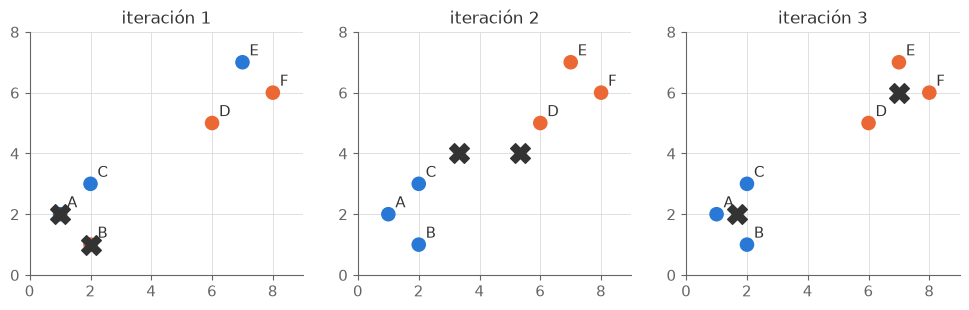

inercia final J = 6.67


,asignación,centroide 1,centroide 2
iteración,,,
1,"{A, C, E} / {B, D, F}","(3.33, 4.0)","(5.33, 4.0)"
2,"{A, B, C} / {D, E, F}","(1.67, 2.0)","(7.0, 6.0)"
3,"{A, B, C} / {D, E, F}","(1.67, 2.0)","(7.0, 6.0)"


In [4]:
lloyd_by_hand(init=('A', 'B'))

**Respuesta.** Sí: en la iteración 2 ya separa {A, B, C} de {D, E, F}. Aquí funciona porque los grupos están muy separados; con datos reales un mal inicio puede dejar a K-Means en un mínimo local (sección 4.2).

### 3.2 Silueta de un punto

In [5]:
silhouette_by_hand('A')

a(A) = distancia media a su grupo   = 1.41
b(A) = distancia media al otro grupo = 7.23
s(A) = (b - a) / max(a, b)           = 0.80


**Lectura.** A está a 1,41 de su grupo y a 7,23 del otro: silueta 0,80, muy bien asignado.

### 3.3 DBSCAN con un punto extra, G = (5, 1)

🔮 **Prediga:** con radio 2,3, ¿a qué grupo va G?

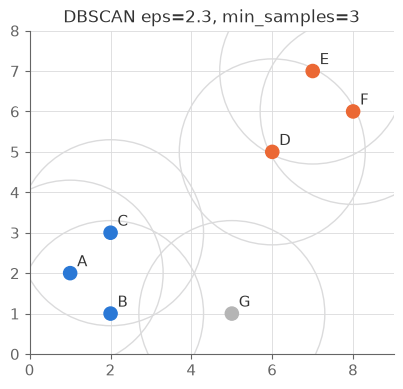

,A,B,C,D,E,F,G
etiqueta (-1 = ruido),0,0,0,1,1,1,-1


In [6]:
dbscan_by_hand(eps=2.3, min_samples=3)

**Respuesta.** A ninguno: su vecino más cercano está a 3,0. DBSCAN lo marca como **ruido (−1)** y encuentra los 2 grupos sin que le digamos $k$.

<a name="4"></a>
## 4. K-Means

### 4.1 Cuándo falla

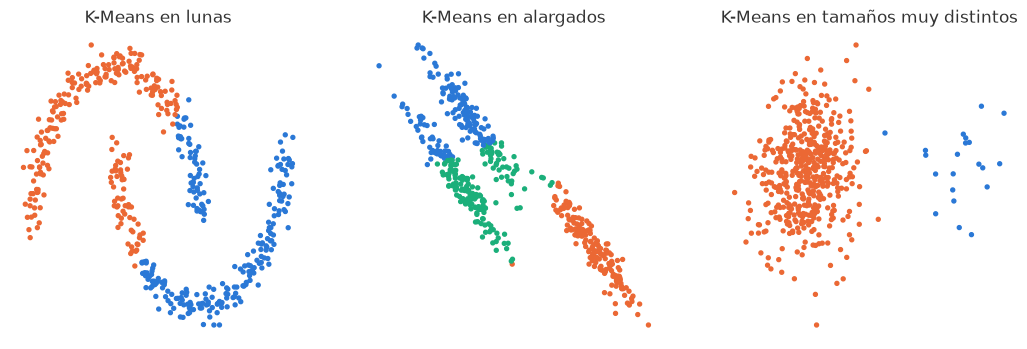

In [7]:
plot_kmeans_failures()

👀 **Qué mirar:** K-Means corta con líneas rectas a mitad de camino entre centroides. Funciona con grupos redondos y parecidos; con lunas, grupos alargados o tamaños muy distintos da una partición limpia y equivocada.

### 4.2 El inicio importa

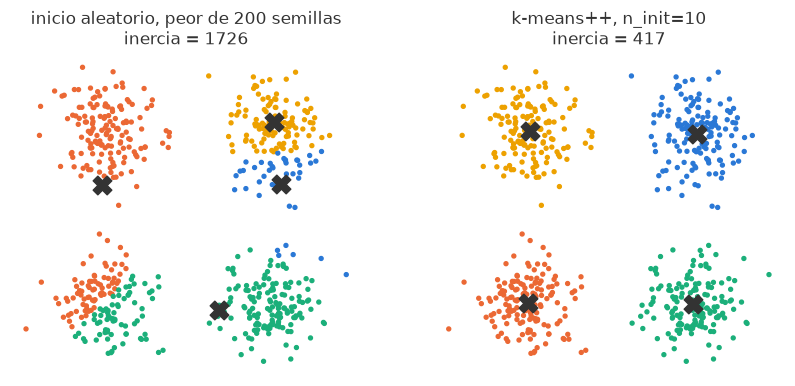

semillas con inercia > 5 % peor que la mejor: 8.5%


In [8]:
plot_init()

**Lectura.** Con un inicio aleatorio malo, dos grupos quedan fusionados y la inercia es 4 veces mayor. `k-means++` reparte los inicios y `n_init=10` repite y se queda con el mejor.

### 4.3 ¿Mini-Batch es más rápido?

🔮 **Prediga:** con 300 mil filas, ¿cuál termina antes?

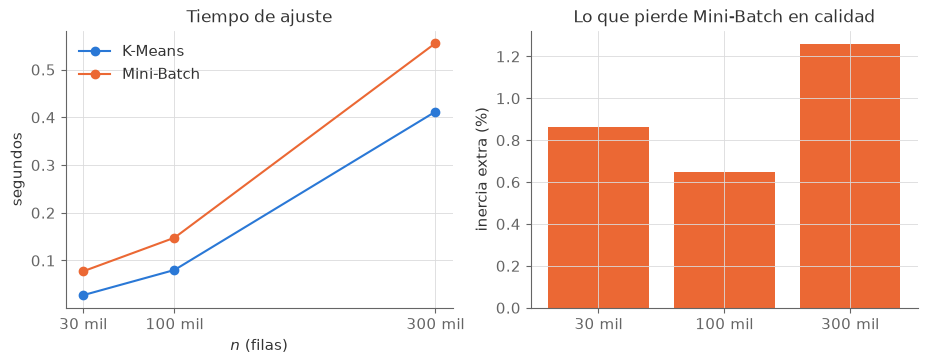

In [9]:
plot_minibatch()

**Respuesta.** En una laptop, el K-Means de scikit-learn suele ser **igual o más rápido** a esta escala, y Mini-Batch pierde algo de calidad. Mini-Batch sirve cuando los datos no caben en memoria o llegan por partes (`partial_fit`). Moraleja: medir antes de asumir.

<a name="5"></a>
## 5. Otras familias

### 5.1 Jerárquico: el dendrograma

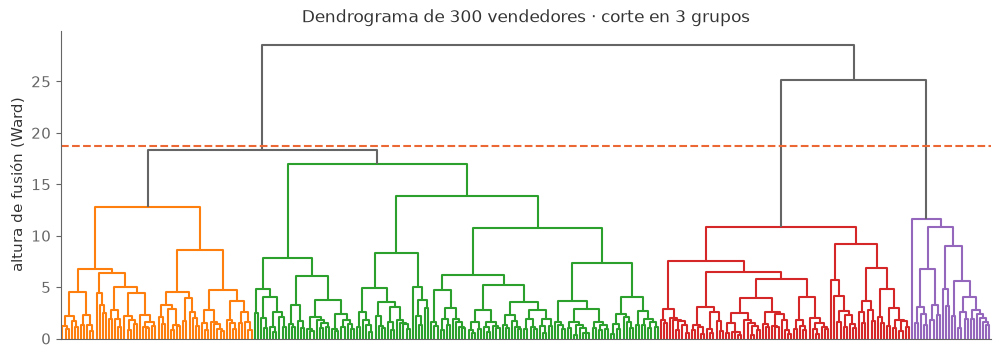

In [10]:
plot_dendrogram(X)

👀 **Qué mirar:** la altura de cada unión es qué tan distintos eran los grupos que se fusionaron. Un salto grande sugiere dónde cortar. Aquí no hay un salto enorme: los vendedores forman más un continuo que islas.

### 5.2 Densidad: DBSCAN frente a HDBSCAN

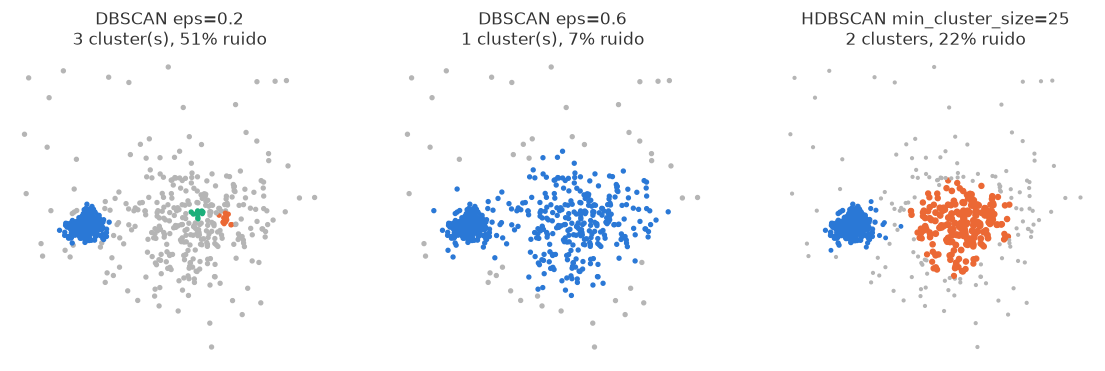

In [11]:
plot_dbscan_vs_hdbscan()

👀 **Qué mirar:** hay un grupo denso y uno ralo. Con `eps` chico DBSCAN rompe el ralo en ruido; con `eps` grande lo une todo. HDBSCAN prueba todos los `eps` y encuentra los dos (gris = ruido).

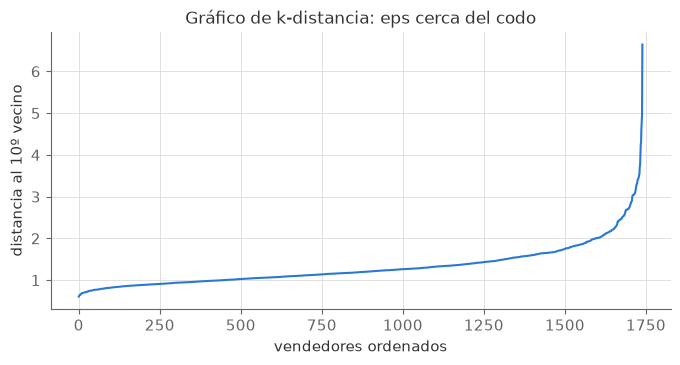

In [12]:
plot_kdistance(X)

**Lectura.** En los vendedores la curva sube suave, sin codo claro: no hay zonas densas separadas por zonas vacías. Un método de densidad aquí marcaría mucho ruido o un solo grupo.

### 5.3 Cuatro algoritmos, cuatro formas

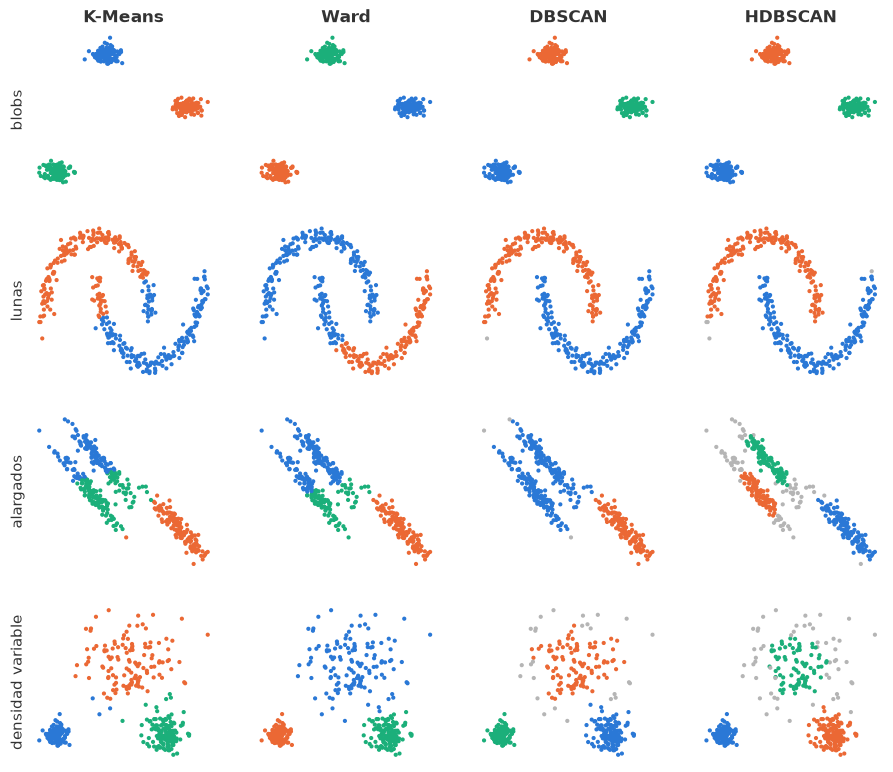

In [13]:
plot_algorithm_grid()

💬 **Discuta:** ¿hay un algoritmo que gane en todas las filas?

**Respuesta.** No. Blobs: todos. Lunas: solo densidad. Densidad variable: K-Means y Ward. Por eso el taller pide comparar al menos dos familias.

### 5.4 Las métricas también tienen preferencias

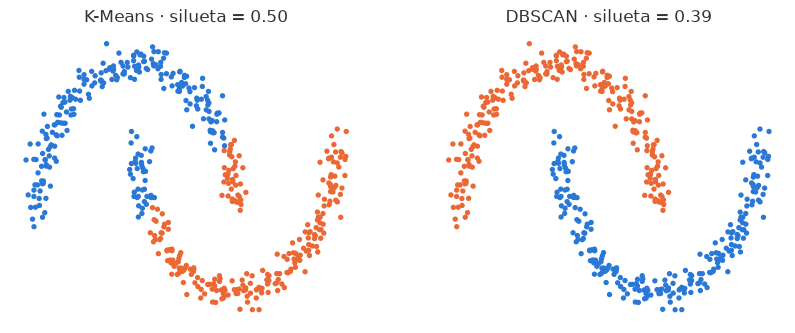

In [14]:
plot_moons_silhouette()

**Lectura.** DBSCAN encuentra las dos lunas y aun así tiene **peor** silueta que K-Means. La silueta premia grupos redondos y compactos; no sirve para comparar familias distintas sin mirar los datos.

<a name="6"></a>
## 6. Elegir $k$ en los vendedores

Para cada $k$: inercia, silueta, Davies–Bouldin, Calinski–Harabasz, **estabilidad** (ARI entre el ajuste completo y 10 submuestras del 80 %) y el tamaño del grupo más chico.

In [15]:
tabla_k = k_table(X)
tabla_k.style.format({"inercia": "{:,.0f}", "silueta ↑": "{:.3f}", "Davies-Bouldin ↓": "{:.2f}",
                      "Calinski-Harabasz ↑": "{:.0f}", "ARI medio ↑": "{:.2f}", "grupo más chico": "{:.0%}"})

,inercia,silueta ↑,Davies-Bouldin ↓,Calinski-Harabasz ↑,ARI medio ↑,grupo más chico
k,,,,,,
2,"11,244",0.185,1.87,414,0.97,47%
3,"9,533",0.202,1.59,400,0.83,18%
4,"8,319",0.177,1.53,390,0.91,12%
5,"7,639",0.174,1.56,357,0.85,11%
6,"7,138",0.157,1.56,330,0.86,10%
7,"6,720",0.164,1.58,309,0.81,8%
8,"6,396",0.169,1.55,291,0.77,5%


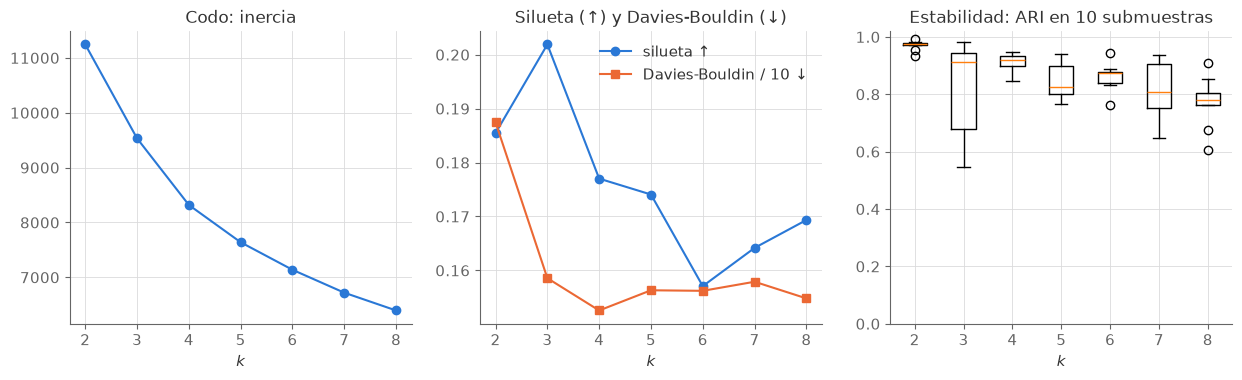

In [16]:
plot_k_evidence(tabla_k)

👀 **Qué mirar:**

- **codo:** no hay uno nítido;
- **silueta:** máxima en $k = 3$, pero baja (0,20): grupos que se tocan;
- **Davies–Bouldin:** mejor en $k = 4$;
- **ARI:** $k = 2$ y $k = 4$ son los más estables; en $k = 3$ la caja es ancha: en algunas submuestras un grupo se reparte distinto.

El ARI también es una estimación: con otras 10 submuestras el de $k = 3$ cambia un poco (en las slides sale 0,87, aquí ~0,83). Por eso se reporta la caja, no un solo número.

💬 **Discuta:** las métricas no coinciden. ¿Cómo decide?

**Respuesta.** Ninguna métrica decide sola. $k = 3$ tiene la mejor silueta y ningún grupo diminuto; $k = 4$ tiene mejor Davies–Bouldin y es más estable. Están casi empatados: decide el negocio. Con $k = 3$ cada grupo pide una acción distinta (sección 7); $k = 4$ solo vale la pena si el cuarto grupo también la pide.

<a name="7"></a>
## 7. De cluster a segmento

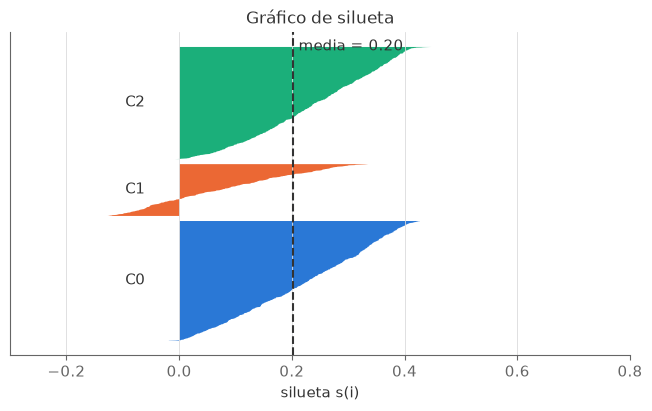

In [17]:
segmentos = fit_segments(X, sellers, k=3)
plot_silhouette(X, segmentos)

👀 **Qué mirar:** pocas barras negativas (pocos mal asignados), pero valores bajos en general: los segmentos existen, con fronteras difusas.

### 7.1 Perfiles en las variables originales

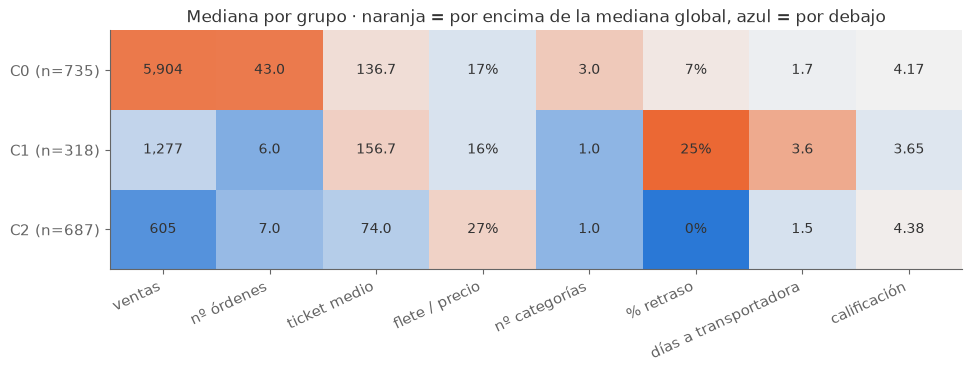

,ventas,nº órdenes,ticket medio,flete / precio,nº categorías,% retraso,días a transportadora,calificación,tamaño
c,,,,,,,,,
0,5903.60,43.0,136.67,0.17,3.0,0.07,1.69,4.17,735
1,1277.24,6.0,156.75,0.16,1.0,0.25,3.64,3.64,318
2,604.90,7.0,73.99,0.27,1.0,0.00,1.46,4.38,687


In [18]:
plot_profiles(sellers, segmentos)

**Lectura y nombres:**

| Segmento | Evidencia | Acción |
|---|---|---|
| **C0 · Grandes y diversificados** | muchas órdenes, más ventas, más categorías | cuenta clave, soporte dedicado |
| **C1 · Con problemas de entrega** | ~25 % de retraso, más días hasta la transportadora, peor calificación | plan logístico, alertas de despacho |
| **C2 · Pequeños de ticket bajo** | ticket bajo, flete caro respecto al precio, sin retrasos | consolidar flete, incentivos para crecer |

💬 **Discuta:** si C0 y C2 terminaran con la misma acción, ¿cuántos segmentos hay para el negocio?

**Respuesta.** Dos. Un segmento existe si cambia lo que hacemos.

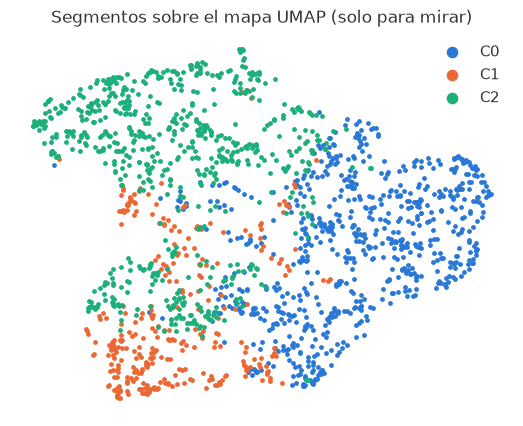

In [19]:
plot_segments_map(X, segmentos)

**Lectura.** Los segmentos se calcularon en las 8 variables, no en el mapa. El mapa UMAP solo sirve para mirarlos: se ven zonas de color, con mezcla en los bordes, como dice la silueta.

<a name="8"></a>
## 8. Outliers: lo que no encaja

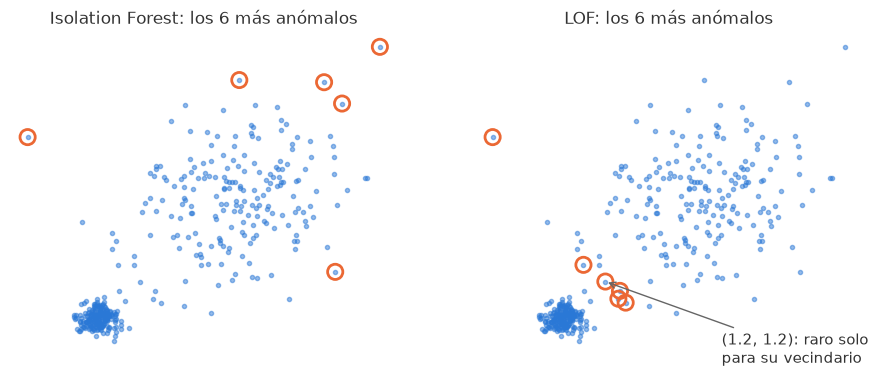

In [20]:
plot_if_vs_lof()

👀 **Qué mirar:** Isolation Forest marca lo raro respecto a **todos** (los puntos más lejanos). LOF marca lo raro respecto a **sus vecinos**: puntos cerca del grupo denso pero mucho menos densos que él.

In [21]:
olist_outliers(X, sellers)

Isolation Forest: 18 · LOF: 18 · ambos: 7


,todos (mediana),marcados por IF (mediana)
ventas,1773.26,1292.44
nº órdenes,13.00,6.00
ticket medio,111.71,131.97
flete / precio,0.20,0.50
nº categorías,2.00,1.00
% retraso,0.06,0.53
días a transportadora,1.76,9.08
calificación,4.17,2.67


**Lectura.** El 1 % más raro según Isolation Forest tiene ~50 % de retraso, ~9 días para entregar a la transportadora y calificación ~2,7. IF y LOF coinciden solo en parte.

💬 **Discuta:** ¿los borramos antes de segmentar?

**Respuesta.** No sin investigar. Pueden ser errores de datos, pero aquí parecen vendedores con problemas operativos serios: justo los que el negocio necesita encontrar.

<a name="9"></a>
## 9. Drift: cuando el mundo cambia

🔮 **Prediga:** ¿la tasa de retraso de Olist es estable mes a mes?

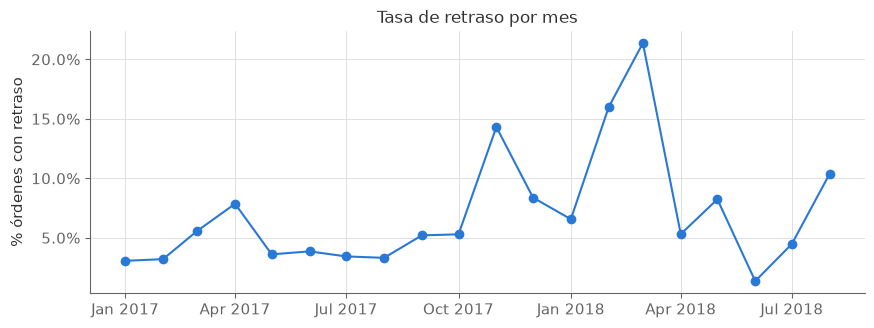

In [22]:
ordenes = load_orders(con)
plot_late_monthly(ordenes)

**Respuesta.** No. Pasa de ~3 % a 14 % en noviembre de 2017 (Black Friday) y a 21 % en marzo de 2018. Un modelo de retrasos entrenado con 2017 ve otro mundo en 2018.

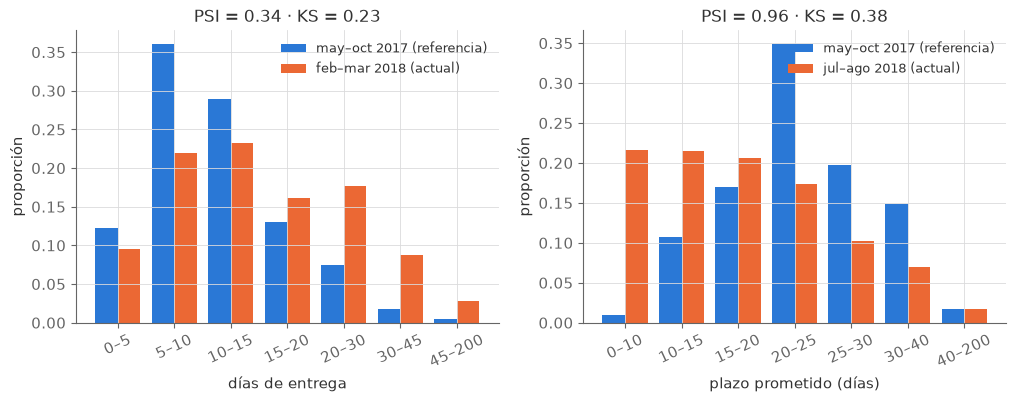

,periodo actual,mediana ref.,mediana actual,PSI,KS
variable,,,,,
días de entrega,feb–mar 2018,10.17,14.00,0.34,0.23
plazo prometido (días),jul–ago 2018,22.67,16.42,0.96,0.38


In [23]:
plot_drift(ordenes)

**Lectura.** PSI < 0,1 estable; 0,1–0,25 vigilar; > 0,25 cambio fuerte.

- **Días de entrega**, feb–mar 2018 frente a may–oct 2017: PSI ≈ 0,34, la mediana sube de ~10 a ~14 días.
- **Plazo prometido**, jul–ago 2018: PSI ≈ 0,96. Olist empezó a prometer entregas mucho más cortas.

💬 **Discuta:** el plazo prometido cambió por una decisión del negocio, no por el comportamiento de los clientes. ¿Igual hay que reentrenar el modelo de retrasos?

**Respuesta.** Sí: "retraso" se define contra el plazo prometido. Si el plazo cambia, cambia lo que significa la etiqueta (drift de concepto).

<a name="10"></a>
## 10. Para seguir practicando

1. **Otra familia:** segmente con `AgglomerativeClustering(3, linkage="ward")` y compare con K-Means usando `adjusted_rand_score`.
2. **HDBSCAN sobre UMAP:** `Y = run_umap(X, n_components=10, min_dist=0)` y luego `HDBSCAN(min_cluster_size=30).fit_predict(Y)`. ¿Cuánto ruido sale? Perfile en las variables originales.
3. **$k = 4$:** repita los perfiles. ¿El cuarto grupo pide una acción distinta?
4. **Clientes (taller, Módulo C):** misma receta con `customer_unique_id`.

**La idea que debe quedar:** siempre hay clusters, no siempre hay segmentos. Un segmento es nombrable, estable, accionable y de tamaño útil, y se valida con varias métricas, otra semilla y el negocio.

---
**Curso:** Aprendizaje Automático — SI7009 · Universidad EAFIT · Sesión 6